# Auditing what the selected method merged

**The question.** Of the pairs the selected clustering actually placed together, how many are wrong?
This is the quantity a catalogue depends on, and neither of the two preceding notebooks estimates
it. Notebook 3 scored pairs drawn by similarity from the whole corpus; notebook 4 scored pairs drawn
from the region where three methods disagree, which is the hardest material in the corpus by
construction. Both answer *how good is the method*. This one answers *how good is its output*.

**The evidence.** 150 pairs drawn from inside the selected clustering's own clusters, stratified by
how central each crop sits in its cluster, judged blind in the same three-way scheme used throughout
the chapter. The draw uses equal centrality quotas and at most one pair per cluster per stratum. It
therefore estimates stratum-specific rates under this balanced audit design, not the pair-weighted
error of the shortlist or of the clustering as a whole.

**What it produces.** Descriptive false-merge rates for the three audit strata and a measurement
of where in a cluster the observed errors live.

**How to read it.** Section 2 states what this sample estimates and checks the frozen draw. Sections
3 and 4 measure the error rate and test whether it varies from the centre of a cluster to its edge.
Section 5 looks at the same pairs by cluster size, and finds two gradients running in opposite
directions. Section 6 states what follows for the catalogue.

## 1. Configuration and inputs

The audit pairs and their judgements are frozen artifacts of the chapter and are read, never
regenerated: re-drawing the sample would discard 150 completed human labels. The clustering itself
is read as the label vector notebook 3 froze.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest, norm

NOTEBOOK_DIR = Path.cwd().resolve()
assert NOTEBOOK_DIR.name == '2_clustering', \
    'Run this notebook from its own folder, 2_clustering/.'
PROJECT_DIR = NOTEBOOK_DIR.parent

RUN_TAG = '_rerun1'
ALLOW_OVERWRITE = False


def guarded_mkdir(path):
    """Create an output directory, refusing to overwrite a populated one."""
    if path.exists() and any(path.iterdir()) and not (RUN_TAG or ALLOW_OVERWRITE):
        raise RuntimeError(
            f'{path} already contains results. Set RUN_TAG to write elsewhere, '
            f'or ALLOW_OVERWRITE = True to replace them.')
    path.mkdir(parents=True, exist_ok=True)


RANDOM_SEED = 42
FEATURE_RUN_ID = 'all_regions_v1_minside24_dinov2_vitb14_binarized_v1'
BENCHMARK_DIR = PROJECT_DIR / '2_clustering_outputs' / f'{FEATURE_RUN_ID}_clustering_benchmark_v1'
METHOD_DIR = BENCHMARK_DIR / 'method_comparison'
AUDIT_DIR = BENCHMARK_DIR / 'within_cluster_audit_v1'
OUTPUT_DIR = BENCHMARK_DIR / f'audit_analysis_v1{RUN_TAG}'
FIGURES_DIR = OUTPUT_DIR / 'figures'
guarded_mkdir(OUTPUT_DIR)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

STRATA = ['core-core', 'core-edge', 'edge-edge']
SIZE_BANDS = [0, 25, 100, 10 ** 6]
SIZE_LABELS = ['under 25', '25 to 100', 'over 100']

cluster_labels = np.load(METHOD_DIR / 'selected_cluster_labels.npy')
cluster_sizes = pd.Series(cluster_labels[cluster_labels >= 0]).value_counts()

audit = pd.read_csv(AUDIT_DIR / 'audit_pair_candidates.csv').merge(
    pd.read_csv(AUDIT_DIR / 'audit_pair_labels.csv')[['pair_id', 'label']], on='pair_id')
audit['cluster_size'] = audit.cluster_id.map(cluster_sizes)
audit['size_band'] = pd.cut(audit.cluster_size, SIZE_BANDS, labels=SIZE_LABELS)
audit['is_false_merge'] = audit.label.eq('different')
audit['is_non_fleuron'] = audit.label.eq('non_fleuron')

identity = audit[audit.label.isin(['same_fleuron', 'different'])].copy()
print(f'audit pairs          : {len(audit)}')
print(f'usable for identity  : {len(identity)}  '
      f'({int(audit.is_non_fleuron.sum())} set aside as non-fleuron)')
print(f'clusters represented : {audit.cluster_id.nunique()}')

audit pairs          : 150
usable for identity  : 103  (47 set aside as non-fleuron)
clusters represented : 55


## 2. What this sample estimates, and whether the draw is sound

The three notebooks use different sampling frames, and the distinction is the reason this one
exists.

| notebook | sampling frame | defensible reading |
|---|---|---|
| 3 | pairs drawn by DINO similarity from the whole corpus | can a threshold or method separate the labelled pairs |
| 4 | cluster-capped sample where candidate methods disagree | descriptive comparison on contested pairs |
| **6** | **equal centrality quotas, nearly equal cluster influence inside the shortlist** | **error structure across the audit strata** |

Within a cluster, crops are ordered by **centrality**, the cosine similarity between a crop and its
cluster's centroid. Central and peripheral are the top and bottom **terciles** of that ordering, and
the sample is stratified into pairs of two central members, one central and one peripheral, and two
peripheral members. No cluster contributes more than one pair per stratum. This prevents one large
cluster dominating the audit, but it has two consequences for the pooled figure: a pair involving a
middle-tercile crop is outside the frame, so the three strata cover four ninths of the pairs the
shortlist merges, and within that coverage the quotas are balanced rather than proportional.

The 55 shortlisted clusters hold 5,017 of the 7,160 assigned crops. The draw gives each centrality
stratum 50 slots and nearly equal influence to clusters whose numbers of possible pairs differ by
orders of magnitude. The defensible primary results are therefore the three stratum-specific rates.
The pooled 6/103 rate describes this balanced audit design, and it cannot be scaled to the whole
shortlist, because 65% of the shortlist's within-cluster pair mass sits in a single cluster that
contributes at most three audited pairs. It says nothing about the 85 excluded clusters. It is also
not the error rate of the catalogue, for a reason unrelated to weighting: every catalogue crop was
confirmed by eye afterwards, so this is the error of the unreviewed output, which is what the human
step exists to remove.

The draw is frozen. What can still be verified is its internal consistency, which the assertions
below do.

In [2]:
assert len(audit) == 150 and audit.pair_id.is_unique
assert (audit.left_index != audit.right_index).all(), 'a pair repeats one crop'
assert not audit.duplicated(['left_index', 'right_index']).any(), 'a pair is drawn twice'
assert audit.stratum.value_counts().eq(50).all(), 'strata are unbalanced'
assert audit.groupby(['cluster_id', 'stratum']).size().max() == 1, 'a cluster repeats a stratum'
assert audit.label.isin(['same_fleuron', 'different', 'non_fleuron']).all()
assert cluster_labels[audit.left_index.to_numpy()].tolist() == audit.cluster_id.tolist()
assert cluster_labels[audit.right_index.to_numpy()].tolist() == audit.cluster_id.tolist()

# Centrality must actually separate the strata, otherwise the design measures nothing.
centrality = audit[['left_centrality', 'right_centrality']]
profile = pd.DataFrame({
    'pairs': audit.groupby('stratum').size(),
    'clusters': audit.groupby('stratum').cluster_id.nunique(),
    'min_centrality': centrality.min(axis=1).groupby(audit.stratum).median().round(3),
    'max_centrality': centrality.max(axis=1).groupby(audit.stratum).median().round(3),
}).reindex(STRATA)
display(profile)
print(f'clusters audited: {audit.cluster_id.nunique()}, '
      f'sizes {int(audit.cluster_size.min())} to {int(audit.cluster_size.max())} crops, '
      f'median {audit.cluster_size.median():.0f}')

,pairs,clusters,min_centrality,max_centrality
stratum,,,,
core-core,50,50,0.963,0.972
core-edge,50,50,0.929,0.966
edge-edge,50,50,0.919,0.936


clusters audited: 55, sizes 16 to 1115 crops, median 46


**Takeaway.** Every structural property the design claims is present: 150 unique pairs, no crop
paired with itself, no pair drawn twice, exactly 50 per stratum, and no cluster contributing two
pairs to the same stratum. Every audited crop really does carry the cluster label recorded for it.
The strata are separated on centrality as intended, so the core-to-edge contrast measures what it
is supposed to measure.

The sample covers 55 clusters spanning 16 to 1,115 crops, so it is not concentrated on a handful of
large groups.

## 3. How often the method merged two different designs

Pairs judged `non_fleuron` are set aside here rather than counted as errors. Whether a crop is a
usable ornament and whether two crops show the same design are different questions, and merging two
crops of the same printer's rule is a correct grouping decision even though the result has no place
in a catalogue. Section 5 returns to those pairs on their own terms.

Intervals are Wilson rather than normal approximation, which matters at these counts. Because at
most three pairs come from one cluster, the pairs are not fully independent, so a cluster bootstrap
is reported beside the Wilson interval: clusters are resampled with replacement and the rate
recomputed, which propagates the dependence the binomial interval ignores.

In [3]:
def wilson_interval(successes, total):
    if total == 0:
        return np.nan, np.nan
    low, high = binomtest(int(successes), int(total)).proportion_ci(0.95)
    return float(low), float(high)


def cluster_bootstrap(frame, column, draws=5000, seed=RANDOM_SEED):
    """Resample whole clusters with replacement and recompute the rate."""
    generator = np.random.default_rng(seed)
    groups = [group[column].to_numpy() for _, group in frame.groupby('cluster_id')]
    if not groups:
        return np.nan, np.nan
    rates = np.empty(draws)
    for draw in range(draws):
        picked = generator.integers(0, len(groups), len(groups))
        values = np.concatenate([groups[index] for index in picked])
        rates[draw] = values.mean()
    return float(np.quantile(rates, 0.025)), float(np.quantile(rates, 0.975))


rows = []
for stratum in STRATA:
    group = identity[identity.stratum == stratum]
    wrong, total = int(group.is_false_merge.sum()), len(group)
    low, high = wilson_interval(wrong, total)
    boot_low, boot_high = cluster_bootstrap(group, 'is_false_merge')
    rows.append({'stratum': stratum, 'identity_pairs': total, 'false_merges': wrong,
                 'false_merge_rate': wrong / total,
                 'wilson_lower': low, 'wilson_upper': high,
                 'cluster_bootstrap_lower': boot_low, 'cluster_bootstrap_upper': boot_high})
overall_wrong, overall_total = int(identity.is_false_merge.sum()), len(identity)
overall_low, overall_high = wilson_interval(overall_wrong, overall_total)
rows.append({'stratum': 'all pairs', 'identity_pairs': overall_total,
             'false_merges': overall_wrong, 'false_merge_rate': overall_wrong / overall_total,
             'wilson_lower': overall_low, 'wilson_upper': overall_high,
             **dict(zip(['cluster_bootstrap_lower', 'cluster_bootstrap_upper'],
                        cluster_bootstrap(identity, 'is_false_merge')))})
by_stratum = pd.DataFrame(rows)
by_stratum.to_csv(OUTPUT_DIR / 'false_merge_by_stratum.csv', index=False)
display(by_stratum.round(3).set_index('stratum'))

,identity_pairs,false_merges,false_merge_rate,wilson_lower,wilson_upper,cluster_bootstrap_lower,cluster_bootstrap_upper
stratum,,,,,,,
core-core,37,0,0.000,0.000,0.095,0.000,0.000
core-edge,34,2,0.059,0.007,0.197,0.000,0.147
edge-edge,32,4,0.125,0.035,0.290,0.031,0.250
all pairs,103,6,0.058,0.022,0.122,0.010,0.117


**Takeaway.** Of the 103 usable identity judgements, **six are false merges, a pooled audit-sample
rate of 5.8% [2.2%, 12.2%]**. Reweighted from the equal quotas to the tercile-implied composition of
the region the design covers, 25/50/25 rather than 33/33/33, the figure is 6.1%: the balance across
centrality strata is worth about two tenths of a point. What the pooled figure cannot be scaled to
is the whole shortlist or the catalogue, for the reasons in Section 2. The primary results are the
stratum-specific counts below.

The rate is not uniform inside a cluster. **No false merge appears among 37 pairs of central
members**, two among 34 central-to-peripheral pairs, and four among 32 pairs of peripheral members.

One caution on the intervals. The cluster bootstrap for the central stratum collapses to
[0.000, 0.000], because a stratum with zero events resamples to zero however the clusters are drawn.
That interval is an artefact of the estimator, not evidence of certainty, and the honest upper bound
for the central stratum is Wilson's 9.5%.

## 4. Is the centre-to-edge gradient real?

Three proportions rising in the predicted order can arise by chance, particularly at these counts,
so the ordering is tested rather than described. The Cochran-Armitage test asks whether the error
rate trends across the ordered strata; because it relies on a normal approximation that is
questionable with six events, an exact permutation test is run beside it, shuffling the labels
across strata and recording how often a trend at least as strong appears.

In [4]:
scores = {'core-core': 0, 'core-edge': 1, 'edge-edge': 2}
identity = identity.assign(stratum_score=identity.stratum.map(scores))


def cochran_armitage(frame):
    n_by = frame.groupby('stratum_score').size()
    x_by = frame.groupby('stratum_score').is_false_merge.sum()
    total, events = int(n_by.sum()), int(x_by.sum())
    proportion = events / total
    doses = n_by.index.to_numpy(dtype=float)
    numerator = float((x_by.to_numpy() * doses).sum() - proportion * (n_by.to_numpy() * doses).sum())
    mean_dose = float((n_by.to_numpy() * doses).sum() / total)
    variance = proportion * (1 - proportion) * float(
        (n_by.to_numpy() * (doses - mean_dose) ** 2).sum())
    z = numerator / np.sqrt(variance)
    return z, 2 * (1 - norm.cdf(abs(z)))


z_statistic, z_pvalue = cochran_armitage(identity)

generator = np.random.default_rng(RANDOM_SEED)
observed = float(np.corrcoef(identity.stratum_score, identity.is_false_merge)[0, 1])
shuffled = identity.is_false_merge.to_numpy().copy()
extreme = 0
DRAWS = 10000
for _ in range(DRAWS):
    generator.shuffle(shuffled)
    if np.corrcoef(identity.stratum_score, shuffled)[0, 1] >= observed:
        extreme += 1
permutation_pvalue = (extreme + 1) / (DRAWS + 1)

core = identity[identity.stratum == 'core-core']
edge = identity[identity.stratum == 'edge-edge']
generator = np.random.default_rng(RANDOM_SEED)
gaps = np.empty(5000)
core_groups = [g.is_false_merge.to_numpy() for _, g in core.groupby('cluster_id')]
edge_groups = [g.is_false_merge.to_numpy() for _, g in edge.groupby('cluster_id')]
for draw in range(5000):
    picked_core = generator.integers(0, len(core_groups), len(core_groups))
    picked_edge = generator.integers(0, len(edge_groups), len(edge_groups))
    gaps[draw] = (np.concatenate([edge_groups[i] for i in picked_edge]).mean()
                  - np.concatenate([core_groups[i] for i in picked_core]).mean())

trend = pd.DataFrame([{
    'cochran_armitage_z': z_statistic, 'cochran_armitage_p': z_pvalue,
    'permutation_p': permutation_pvalue,
    'edge_minus_core': float(edge.is_false_merge.mean() - core.is_false_merge.mean()),
    'gap_ci95_lower': float(np.quantile(gaps, 0.025)),
    'gap_ci95_upper': float(np.quantile(gaps, 0.975)),
    'probability_gap_at_most_zero': float((gaps <= 0).mean()),
}])
trend.to_csv(OUTPUT_DIR / 'centre_to_edge_trend.csv', index=False)
display(trend.round(4).T.rename(columns={0: 'value'}))

,value
cochran_armitage_z,2.2095
cochran_armitage_p,0.0271
permutation_p,0.0069
edge_minus_core,0.1250
gap_ci95_lower,0.0312
gap_ci95_upper,0.2500
probability_gap_at_most_zero,0.0162


**Takeaway.** The observed gradient is consistent across three descriptive calculations. Cochran-Armitage gives *z* = 2.21,
two-sided *p* = 0.027. The permutation test, which asks only about the direction stated in advance,
gives *p* = 0.007 over 10,000 shuffles. A cluster bootstrap of the difference between the peripheral
and central strata puts the gap at 0.125, 95% interval [0.031, 0.250], with a 1.6% probability of
being zero or negative. These inferential values are exploratory: the label permutation does not
preserve clusters, and the edge-minus-core bootstrap does not preserve the matched cluster
structure. A cluster-preserving reanalysis is required before treating them as confirmatory.

The effect has a mechanical explanation rather than a statistical one. Centrality is the similarity
between a crop and its cluster's centroid, so a crop admitted at the edge of a cluster is by
definition the one the method was least sure about. That the errors concentrate there is what a
density-based method should do when it fails, and it is what makes the operating rule of Section 6
possible.

## 5. The same pairs, read by cluster size

Notebook 4 found that HDBSCAN's errors on contested merges rise with the size of the cluster
involved, from 20% below 25 members to 57% above 100. If that is a real property of the method
rather than of the disagreement region, it should appear again here, in a sample drawn on entirely
different principles. This section checks, and reads the `non_fleuron` pairs set aside in Section 3
on the same axis.

In [5]:
rows = []
for band in SIZE_LABELS:
    identity_band = identity[identity.size_band == band]
    all_band = audit[audit.size_band == band]
    wrong, total = int(identity_band.is_false_merge.sum()), len(identity_band)
    low, high = wilson_interval(wrong, total)
    rows.append({'cluster_size': band, 'clusters': int(all_band.cluster_id.nunique()),
                 'identity_pairs': total, 'false_merges': wrong,
                 'false_merge_rate': (wrong / total) if total else np.nan,
                 'wilson_lower': low, 'wilson_upper': high,
                 'audited_pairs': len(all_band),
                 'non_fleuron_rate': float(all_band.is_non_fleuron.mean())})
by_size = pd.DataFrame(rows)
by_size.to_csv(OUTPUT_DIR / 'rates_by_cluster_size.csv', index=False)
display(by_size.round(3).set_index('cluster_size'))

,clusters,identity_pairs,false_merges,false_merge_rate,wilson_lower,wilson_upper,audited_pairs,non_fleuron_rate
cluster_size,,,,,,,,
under 25,10,9,0,0.000,0.000,0.336,26,0.654
25 to 100,33,67,3,0.045,0.009,0.125,92,0.272
over 100,12,27,3,0.111,0.024,0.292,32,0.156


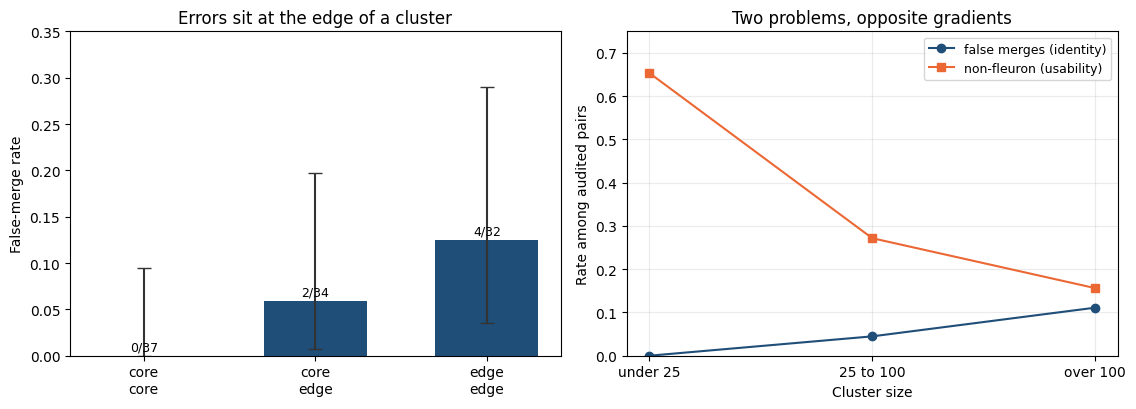

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

stratum_rows = by_stratum[by_stratum.stratum != 'all pairs']
positions = np.arange(len(stratum_rows))
errors = [stratum_rows.false_merge_rate - stratum_rows.wilson_lower,
          stratum_rows.wilson_upper - stratum_rows.false_merge_rate]
axes[0].bar(positions, stratum_rows.false_merge_rate, color='#1f4e79', width=0.6)
axes[0].errorbar(positions, stratum_rows.false_merge_rate, yerr=errors, fmt='none',
                 ecolor='#333333', capsize=5)
axes[0].set(xticks=positions, xticklabels=['core\ncore', 'core\nedge', 'edge\nedge'],
            ylabel='False-merge rate', ylim=(0, 0.35),
            title='Errors sit at the edge of a cluster')
for position, (rate, wrong, total) in enumerate(zip(stratum_rows.false_merge_rate,
                                                    stratum_rows.false_merges,
                                                    stratum_rows.identity_pairs)):
    axes[0].annotate(f'{wrong}/{total}', (position, rate), ha='center',
                     textcoords='offset points', xytext=(0, 4), fontsize=9)

positions = np.arange(len(by_size))
axes[1].plot(positions, by_size.false_merge_rate, marker='o', color='#1f4e79',
             label='false merges (identity)')
axes[1].plot(positions, by_size.non_fleuron_rate, marker='s', color='#eb6834',
             label='non-fleuron (usability)')
axes[1].set(xticks=positions, xticklabels=by_size.cluster_size, xlabel='Cluster size',
            ylabel='Rate among audited pairs', ylim=(0, 0.75),
            title='Two problems, opposite gradients')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.25)

figure.tight_layout()
figure.savefig(FIGURES_DIR / 'audit_error_structure.png', dpi=180, bbox_inches='tight')
plt.show()

**Takeaway.** The size effect reappears. False merges rise from **0 of 9** pairs in clusters under 25
crops, to 4.5% between 25 and 100, to **11.1%** above 100. The direction matches notebook 4, which
found the same ordering in a sample built on different principles. With only 9, 67, and 27 usable
pairs in the three bands and overlapping intervals, this is suggestive rather than an independent
replication. Large clusters are a plausible location for a density method to absorb a neighbouring
design, but the present sample does not establish that mechanism.

The `non_fleuron` rate runs the other way, and steeply: **65%** of audited pairs in clusters under 25
crops involve material that is not a usable ornament, against 27% between 25 and 100 and **16%**
above 100.

The two gradients together describe the workflow honestly. **Small clusters are mostly a usability
problem and large clusters are mostly an identity problem.** A reviewer discarding small clusters is
removing noise, and a reviewer inspecting a large cluster is looking for an intruder. This is a more
useful instruction to the next researcher than a single pooled error rate, and neither gradient is
visible in a pooled figure.

## 6. What follows for the catalogue

The audit is the point at which the chapter can state what its output is worth, and the numbers
support a narrower claim than "the clustering is accurate".

In [7]:
core_pairs = identity[identity.stratum == 'core-core']
core_low, core_high = wilson_interval(int(core_pairs.is_false_merge.sum()), len(core_pairs))
clusters_with_errors = (identity[identity.is_false_merge].cluster_id.unique())

summary = pd.DataFrame([
    {'claim': 'false-merge rate over all audited pairs',
     'value': f'{overall_wrong}/{overall_total} = {overall_wrong / overall_total:.3f}',
     'interval': f'[{overall_low:.3f}, {overall_high:.3f}]'},
    {'claim': 'false-merge rate among central members',
     'value': f'{int(core_pairs.is_false_merge.sum())}/{len(core_pairs)} = 0.000',
     'interval': f'[{core_low:.3f}, {core_high:.3f}]'},
    {'claim': 'clusters containing at least one observed false merge',
     'value': f'{len(clusters_with_errors)} of {audit.cluster_id.nunique()} audited',
     'interval': ''},
    {'claim': 'audited pairs that are not usable ornaments',
     'value': f'{int(audit.is_non_fleuron.sum())}/{len(audit)} = '
              f'{audit.is_non_fleuron.mean():.3f}',
     'interval': ''},
])
summary.to_csv(OUTPUT_DIR / 'audit_summary.csv', index=False)
pd.DataFrame({'cluster_id': clusters_with_errors}).to_csv(
    OUTPUT_DIR / 'clusters_with_false_merges.csv', index=False)
display(summary.set_index('claim'))

,value,interval
claim,,
false-merge rate over all audited pairs,6/103 = 0.058,"[0.022, 0.122]"
false-merge rate among central members,0/37 = 0.000,"[0.000, 0.095]"
clusters containing at least one observed false merge,5 of 55 audited,
audited pairs that are not usable ornaments,47/150 = 0.313,


**The operating rule.** Historical claims are made from central cluster members. Zero false merges
appear among 37 such pairs, with a Wilson upper bound of 9.5%, against a rate of 12.5% at the edge. This is not a claim that central members are error-free, it is a claim that the error is
bounded where it has been measured and is demonstrably lower than at the periphery.

**Five of the 55 audited clusters account for every observed false merge.** The errors are not spread
thinly across the clustering, they are concentrated in identifiable groups, which is what makes
review tractable rather than hopeless.

**Just under a third of audited pairs, 47 of 150, are not usable ornaments at all.** That figure belongs beside the
false-merge rate rather than inside it. The clustering is being asked to do two jobs, separate
designs and exclude non-ornaments, and it is measurably better at the first than the second. The
crop filter and the human triage that follow are what handle the second.

**What the human step is worth.** Notebook 4 measured a 40% error rate on the merges HDBSCAN makes
unilaterally. This notebook observes 6 errors among 103 usable judgements in its deliberately
balanced audit, and 0 of 37 at cluster centres. The samples target different events, so their
pooled percentages must not be interpreted as estimates of one population. The centrality counts
still provide a practical reason to inspect cluster edges before treating groups as identities.

## 7. Conclusion

**The balanced shortlist audit observed six false merges among 103 usable identity judgements**
(5.8% [2.2%, 12.2%] as an audit-sample summary, 6.1% reweighted to the tercile-implied composition
of the region it covers). The draw gives equal quotas to centrality strata and nearly equal
influence to clusters, and 65% of the shortlist's pair mass sits in one cluster, so this is not an
estimate of the pair-weighted error across the shortlist. It is not the catalogue's error rate
either: the catalogue was reviewed by eye after this stage.

**The observed errors are structured.** They rise from the centre of a cluster to its edge, 0 of 37
against 4 of 32, and concentrate in five of the 55 audited clusters. The current trend tests are
exploratory until rerun with cluster-preserving inference. The cluster-size ordering, 0/9, 3/67, and
3/27, is suggestive but too sparse to call an independent replication.

**Contamination by non-ornaments runs the other way**, from 65% of pairs in small clusters to 16% in
large ones, so the two failure modes motivate different review attention.

**What this notebook establishes is a review diagnostic, not a catalogue-wide error bound.** The
centrality-specific counts support inspecting cluster edges and the five observed problem clusters.
Estimating the error across all merges would require inclusion weights this design does not
provide, since the cluster holding most of the pair mass is represented by at most three pairs. The catalogue assembly itself lives in `_tools/match_clusters_to_catalogue.py`,
`_tools/find_duplicate_classes.py`, and `_tools/audit_catalogue.py`, and is reported in README §8.